In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp


from neurodiffeq.conditions import IVP
from neurodiffeq import diff
from neurodiffeq.generators import Generator1D
from neurodiffeq.solvers import Solver1D, Solution1D, BundleSolution1D
from neurodiffeq.networks import FCNN
from neurodiffeq.conditions import BundleIVP 
import torch
import os
from delta_solver_mg_2 import DeltaSolver
from utils_2 import CustomCondition, f_R_reparams, _shape_manager
import yaml
import joblib
import torch.nn as nn

from scipy.stats import qmc
from neurodiffeq.solvers import BundleSolver1D
from neurodiffeq.generators import PredefinedGenerator

from scipy.constants import c as c_ms

from utils import CustomCondition, HS_reparams

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
H_0 = 70.0
h = H_0 / 100.0
Om_r_0 = 5.38*10**(-5)

Om_m_0 = 0.3
Om_L_0 = 1.0 - Om_m_0 - Om_r_0
c_ms = 299792458.0
c = c_ms / 1000.0

b = 1
k_val1 = 0.2
k_val = k_val1 * h
Lambda = 3 * (H_0 ** 2) * (1 - Om_m_0) / c**2

# Parámetros de integración
z_0 = 20.0
z_f = 0.0
b_max = 5.0
a_0 = 1/1001.0
a_f = 1.0
N_0 = np.log(a_0)
N_f = np.log(a_f)
n_0 = abs(N_0)

N_p_0 = N_0 / n_0
N_p_f = N_f / n_0

In [3]:
model = 'Hu-Sawicki'
path = f'/home/javier-pineau/Escritorio/Tesis/Códigos Augusto/f_R_nets_for_multiuse/{model}_nets'

with open(f'{path}/saved_config.yaml') as yaml_file_f_R:
    try:
        Config_f_R = yaml.safe_load(yaml_file_f_R)
    except yaml.YAMLError as exc:
        print(exc)

# Set the range of the independent variable:
z_rescale = z_0 

z_prime_min = 0.0
z_prime_max = 1.0
z_min = z_prime_min
z_max = z_rescale * z_prime_max

# Set the range of the parameters of the bundle:
b_prime_min = float(Config_f_R['b_prime_min'])
b_prime_max = 1.0
b_max = Config_f_R['b_max']
b_min = b_prime_min * b_max

Om_m_0_min = Config_f_R['Om_m_0_min']
Om_m_0_max = Config_f_R['Om_m_0_max']

# Set neural network parameters and renormalizations:
alpha_nominator = Config_f_R['alpha_nominator']
alpha_denominator = Config_f_R['alpha_denominator']
alpha = alpha_nominator / alpha_denominator

# --- CORRECCIÓN AQUÍ: Cargar al 'device' (GPU), no a CPU ---
fR_nets = torch.load(f'{path}/nets_f_R.ph', map_location=device, weights_only=False)

f_R = f_R_reparams(z_0=z_0, b_prime_min=b_prime_min, b_max=b_max, alpha=alpha)

conditions = [
    CustomCondition(f_R.v_reparam),
    CustomCondition(f_R.r_prime_reparam)
]

r_prime_net_index = -1
v_net_index = 2

for i, net in enumerate(fR_nets):
    try:
        fR_nets[i] = net.to(device)
    except Exception:
        pass

r_prime = BundleSolution1D([fR_nets[r_prime_net_index]], [conditions[-1]])
v = BundleSolution1D([fR_nets[v_net_index]], [conditions[0]])





Condiciones iniciales

Entrenamiento

In [4]:

x_net_index = 0
x_condition = CustomCondition(f_R.x_reparam)
x_sol_obj = BundleSolution1D([fR_nets[x_net_index]], [x_condition])


def H_torch_optimized(z, theta, r_prime_sol, v_sol):
    """ Función H(z) normal (para el valor de H) """
    b, Om_m_tensor, H_0 = theta
    z_prime = 1 - (z / z_rescale)
    b_prime = (b / b_max).expand_as(z)
    
    r_val = r_prime_sol(z_prime, b_prime, Om_m_tensor, to_numpy=False).view_as(z)
    v_val = v_sol(z_prime, b_prime, Om_m_tensor, to_numpy=False).view_as(z)
    
    term_fR = ((1 - Om_m_tensor) / 2) * torch.exp(r_val) / v_val
    Om_L = 1.0 - Om_m_tensor - Om_r_0
    inside = Om_L + Om_m_tensor * (z+1)**3 + Om_r_0 * ((z+1)**4)
    
    H_fR = H_0 * torch.sqrt(torch.abs(term_fR))
    H_LCDM = H_0 * torch.sqrt(inside)
    
    return torch.where(z >= z_0, H_LCDM, H_fR)

def dH_dz_analytica_torch(z, theta, r_prime_sol, v_sol, x_sol):
    """
    Cálculo analítico de H'(z) optimizado para GPU.
    Reemplaza a dH_dz_red original para evitar Numpy.
    """
    b, Om_m_tensor, H_0 = theta
    
    # 1. Preparación de datos (Tensores)
    # z ya viene como tensor con gradiente
    z_prime = 1 - (z / z_rescale)
    
    # Broadcasting de b (tensor)
    b_prime = (b / b_max).expand_as(z)
    
    # 2. Inferencia de Redes (to_numpy=False mantiene GPU)
    # Obtenemos r, v, x directamente en la GPU
    r_prime_val = r_prime_sol(z_prime, b_prime, Om_m_tensor, to_numpy=False)
    v_val = v_sol(z_prime, b_prime, Om_m_tensor, to_numpy=False)
    x_val = x_sol(z_prime, b_prime, Om_m_tensor, to_numpy=False)

    # Aseguramos formas
    r_prime_val = r_prime_val.view_as(z)
    v_val = v_val.view_as(z)
    x_val = x_val.view_as(z)

    # r físico = exp(r_prime_net)
    r_phys = torch.exp(r_prime_val)
    
    # --- PARTE A: Derivada f(R) ---
    # Gamma = (r + b) * ((r+b)^2 - 2b) / (4*b*r)
    # Ojo: b aquí es b_prime_val * b_max? En tu código usabas b directamente.
    # Asumimos b_tensor ya es el valor físico.
    b_phys = b # b ya viene físico en theta
    
    # Usamos b_phys para el cálculo de Gamma (ajustar si b debe ser normalizado)
    # En tu código: b_prime * b_max. Aquí b ya es b_tensor.
    
    numer = (r_phys + b_phys) * (((r_phys + b_phys) ** 2) - 2.0 * b_phys)
    denom_gamma = 4.0 * b_phys * r_phys
    Gamma = numer / denom_gamma
    
    denom_z = z + 1.0

    dr_dz = - r_phys * Gamma * x_val / denom_z
    dv_dz = - v_val * (x_val * Gamma + 4.0 - 2.0 * v_val) / denom_z

    # Derivada de H_fR = H0 * sqrt(...)
    # coef1 = 0.25 * (1 - Om)
    coef1 = 0.25 * (1.0 - Om_m_tensor)
    
    # coef2 = sqrt(r / (2v) * (1 - Om))
    term_inside_sqrt = (r_phys / (2.0 * v_val)) * (1.0 - Om_m_tensor)
    coef2 = torch.sqrt(term_inside_sqrt)
    
    # Regla cadena
    term_deriv = (dr_dz / v_val) - (r_phys * dv_dz / (v_val ** 2))
    
    dH_fR = H_0 * (coef1 / coef2) * term_deriv

    # --- PARTE B: Derivada LCDM (Analítica) ---
    Om_L = 1.0 - Om_m_tensor - Om_r_0
    
    inside = Om_L + Om_m_tensor * (z+1)**3 + Om_r_0 * ((z+1)**4)
    # Derivada de lo de adentro respecto a z
    afuera = 3 * Om_m_tensor * (z+1)**2 + 4 * Om_r_0 * ((z+1)**3)
    
    dH_LCDM = H_0 * afuera / (2 * torch.sqrt(inside))

    # --- PARTE C: Mezcla ---
    mask = (z >= z_0)
    dH_final = torch.where(mask, dH_LCDM, dH_fR)
    
    return dH_final


def Geff_torch_optimized(z, k, theta, Lambda_val, r_prime_sol):
    """ Función Geff(z) optimizada """
    b, Om_m_tensor, H_0 = theta
    z_prime = 1 - (z / z_rescale)
    b_prime = (b / b_max).expand_as(z)
    
    r_val = r_prime_sol(z_prime, b_prime, Om_m_tensor, to_numpy=False).view_as(z)
    r_prime_exp = torch.exp(r_val)

    denomFR = 1.0 + (r_prime_exp * Lambda_val) / (Lambda_val * b)
    FR = 1.0 - 2.0 / (b * (denomFR ** 2))
    FRR = 4.0 / (Lambda_val * (b**2) * (denomFR ** 3))

    m = FRR / FR
    epsilon = (k**2) * ((1.0 + z)**2) * m
    term = 1.0 / (3.0 + 1.0 / epsilon)
    Geff_over_G = (1.0 / FR) * (1.0 + term)

    mask = (z >= z_0)
    return torch.where(mask, torch.ones_like(Geff_over_G), Geff_over_G)

<>:62: SyntaxWarning: invalid escape sequence '\O'
<>:62: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_9857/3980380380.py:62: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(z_np, H_np, '-.', linewidth=2, label=f'b={test_b}, $\Omega_m$={test_Om}')


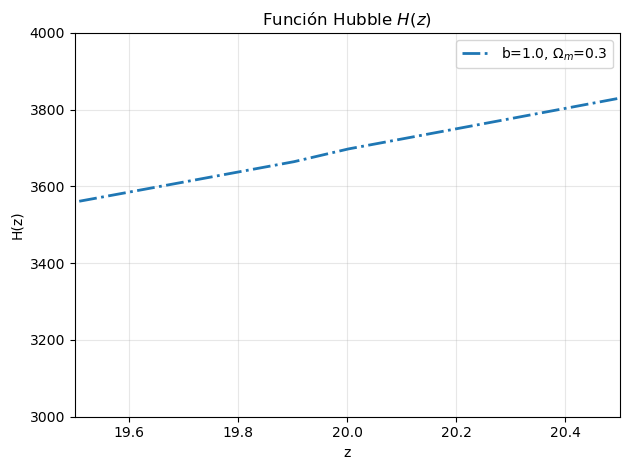

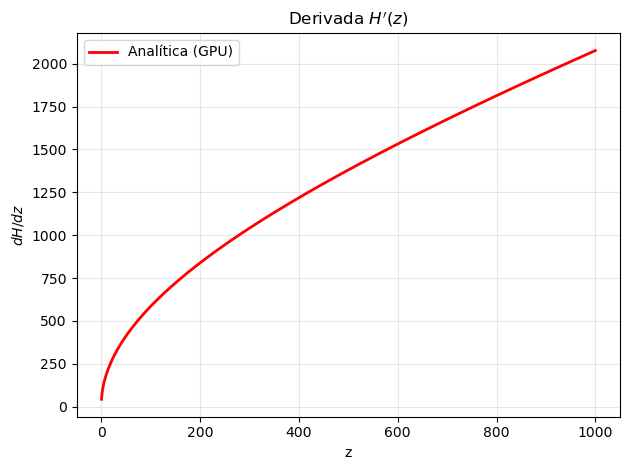

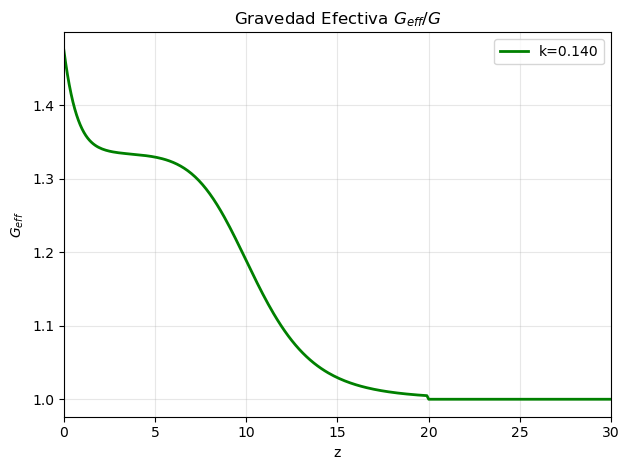

In [7]:
z_min, z_max = 0, 1000
n_points = 10000 # Más puntos para ver bien las curvas
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Parámetros fijos para la visualización
test_b = 1.0          # b fijo
test_Om = 0.3         # Omega_m fijo
test_k = k_val        # k global
test_H0 = H_0         # H0 global
test_Lambda = Lambda  # Lambda global

# 1. Crear vector z en GPU
z_tensor = torch.linspace(z_min, z_max, n_points, device=device)

# 2. Preparar los parámetros en formato Tensor (Broadcasting)
# Creamos tensores llenos con el valor fijo, del mismo tamaño que z
b_tensor = torch.full_like(z_tensor, test_b)
Om_tensor = torch.full_like(z_tensor, test_Om)

# Empaquetamos theta para tus funciones
theta_test = [b_tensor, Om_tensor, test_H0]

# =============================================================================
# CÁLCULOS (Usando tus funciones optimizadas)
# =============================================================================

# A) H(z)
# Nota: Pasamos r_prime y v (los objetos solución que ya tienes cargados)
H_val = H_torch_optimized(z_tensor, theta_test, r_prime, v)

# B) H'(z) = dH/dz (Analítica)
# Nota: Necesitamos x_sol_obj que definiste al principio del bloque anterior
if 'x_sol_obj' not in globals() or x_sol_obj is None:
    print("⚠️ x_sol_obj no encontrado. Intentando crearlo al vuelo...")
    try:
        x_net_index = 0
        x_condition = CustomCondition(f_R.x_reparam)        #dH_g = dH_dz_completo(z_t, theta, r_prime, v).item()

        x_sol_obj = BundleSolution1D([fR_nets[x_net_index]], [x_condition])
    except:
        print("❌ Error: No se puede calcular H' analítica sin la red x (fR_nets).")
        dH_val = torch.zeros_like(z_tensor) # Dummy para no romper el plot
else:
    dH_val = dH_dz_analytica_torch(z_tensor, theta_test, r_prime, v, x_sol_obj)

# C) Geff(z)
Geff_val = Geff_torch_optimized(z_tensor, test_k, theta_test, test_Lambda, r_prime)

# =============================================================================
# GRAFICAR CON MATPLOTLIB
# =============================================================================

# Pasar a Numpy (CPU)
z_np = z_tensor.detach().cpu().numpy()
H_np = H_val.detach().cpu().numpy()
dH_np = dH_val.detach().cpu().numpy()
Geff_np = Geff_val.detach().cpu().numpy()




plt.plot(z_np, H_np, '-.', linewidth=2, label=f'b={test_b}, $\Omega_m$={test_Om}')
plt.title(r'Función Hubble $H(z)$')
plt.xlabel('z')
plt.ylabel('H(z)')
#plt.yscale('log')
plt.grid(True, alpha=0.3, which='both')
plt.legend()
plt.xlim(19.5, 20.5)
plt.ylim(3000, 4000)
plt.tight_layout()
plt.show()

plt.plot(z_np, dH_np, color='red', linewidth=2, label='Analítica (GPU)')
plt.title(r"Derivada $H'(z)$")
plt.xlabel('z')
plt.ylabel(r'$dH/dz$')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()
# Gráfico 3: Geff(z)
plt.plot(z_np, Geff_np, color='green', linewidth=2, label=f'k={test_k:.3f}')
plt.title(r'Gravedad Efectiva $G_{eff}/G$')
plt.xlabel('z')
plt.ylabel(r'$G_{eff}$')
plt.grid(True, alpha=0.3)
plt.xlim(0, 30) # Limitar para ver mejor las variaciones
plt.legend()

plt.tight_layout()
plt.show()

Sin Bundle

In [6]:
def ODE_MG_NN(X, X_p, N_p, k_param, Om_m_0, b, H_0, Lambda):   
    N = N_p * n_0 
    a = torch.exp(N)
    z = (1.0 / a) - 1.0
    
    # --- CORRECCIÓN: Convertir escalares a Tensores ---
    # Como b y Om_m_0 son floats fijos, creamos tensores constantes del tamaño del batch (z)
    # para que las funciones optimizadas (que usan .expand_as) no fallen.
    b_tensor = b * torch.ones_like(z)
    Om_m_tensor = Om_m_0 * torch.ones_like(z)
    
    # Empaquetar theta usando los NUEVOS tensores
    theta_bundle = [b_tensor, Om_m_tensor, H_0]

    # 1. Calcular H y Geff (Torch) usando los tensores
    H_t = H_torch_optimized(z, theta_bundle, r_prime, v)
    mu_t = Geff_torch_optimized(z, k_param, theta_bundle, Lambda, r_prime)

    # 2. Calcular dH/dz (Analítica)
    dH_dz = dH_dz_analytica_torch(z, theta_bundle, r_prime, v, x_sol_obj)
    
    # Regla de la cadena: dH/da = (dH/dz) * (-1/a^2)
    dH_da = dH_dz * (-1.0 / (a ** 2))
    
    # Limpieza
    mu_t = torch.nan_to_num(mu_t, nan=1.0, posinf=1.0, neginf=1.0)

    # EDO Riccati
    # Aseguramos las formas (shapes)
    H_t = H_t.view(-1, 1)
    dH_t = dH_da.view(-1, 1)
    mu_t = mu_t.view(-1, 1)
    
    # Usamos Om_m_tensor aquí también para poder hacer .view()
    Om_m_col = Om_m_tensor.view(-1, 1)
    
    denom = (H_t ** 2) * (a ** 3)
    term1 = n_0 * ((dH_t / H_t) * a + 2)
    pref = (3 * Om_m_col * (n_0 ** 2) * (H_0 ** 2)) / 2
    term2 = pref * (mu_t / denom)

    res1 = diff(X, N_p) - X_p
    res2 = diff(X_p, N_p) + (X_p ** 2) + (term1 * X_p) - term2

    return [res1, res2]

condition = [IVP(N_p_0, -n_0), IVP(N_p_0, n_0)]


def weighted_loss_MG(res, x, t):
    loss = res ** 2
    return loss.mean()


capas = (32, 32,)
learning_rate = 1e-4
nets = [FCNN(n_input_units=1, hidden_units=capas) for _ in range(2)]
adam = torch.optim.Adam(set([p for net in nets for p in net.parameters()]), lr=learning_rate)

batch_size = 64
tgz = Generator1D(batch_size, N_p_0, N_p_f) #, 'equally-spaced-noisy')
vgz = Generator1D(batch_size, N_p_0, N_p_f)

train_gen = tgz
valid_gen = vgz

k_eff = k_val
#solver_clase.k = k_eff



solver_nn = Solver1D(
    ode_system = lambda X, X_p, N_hat: ODE_MG_NN(X, X_p, N_hat, k_eff, Om_m_0, b, H_0, Lambda),
    nets = nets,
    n_batches_valid = 0,
    conditions = condition,
    t_min = N_p_0,
    t_max = N_p_f,
    optimizer = adam,
    train_generator = train_gen,
    valid_generator = valid_gen,
    loss_fn = weighted_loss_MG
)

iterations = 1000000
solver_nn.fit(iterations)
nombre_red_1 =f'opción 2 sin bundle Om = {Om_m_0} k = {k_val}, b= {b} lr = {learning_rate}, iteraciones = {iterations}, batch_size = {batch_size}, {capas}, nueva red'
#nombre_red_1= 'pruebassss'
save_dir  = "/home/javier-pineau/Escritorio/Tesis/Entrenamientos empalme"
os.makedirs(save_dir, exist_ok=True)

loss = solver_nn.metrics_history['train_loss']

plt.figure(figsize=(8,5))
plt.plot(np.arange(len(loss)), loss, label='train_loss')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.title(f'Loss - Iter: {iterations}')
#plt.savefig(os.path.join(save_dir, f'Loss Om ={Om_m_0}, k = {k_eff}, b = {b}, lr = {learning_rate}, iteraciones = {iterations}, batch_size = {batch_size}, hidden units {capas} nueva red.png'))
plt.show()

save_path = os.path.join(save_dir, nombre_red_1 + ".pt")
torch.save(solver_nn._get_internal_variables()['best_nets'], save_path)
print(f"Mejores redes guardadas en: {save_path}")

Training Progress:   0%|          | 0/1000000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [6]:
for net in nets:
    net.eval()

condition = [
    IVP(N_p_0, -n_0),
    IVP(N_p_0,  n_0),
]


sol = Solution1D(nets, condition)


def x_nn(Np_array):
    return sol(Np_array, to_numpy=True)[0]

def y_nn(Np_array):
    return sol(Np_array, to_numpy=True)[1]

Np_vec = np.linspace(N_p_0, N_p_f, 10000).astype(np.float64)  

xN_nb = x_nn(Np_vec)
yN_nb = y_nn(Np_vec)


plt.figure()
plt.plot(Np_vec, xN_nb, label=r'$x(N_p)$')
plt.plot(Np_vec, yN_nb, label=r'$y(N_p)$')
plt.xlabel(r'$N_p$')
plt.ylabel(r'Salida de la red')
plt.legend()
plt.grid(True)

a_vec  = np.exp(n_0 * Np_vec)

delta_nn_nb   = np.exp(xN_nb)
delta_p_nn_nb = delta_nn_nb * yN_nb / (n_0 * a_vec)

N_phys = n_0 * Np_vec
a_phys = np.exp(N_phys)


plt.figure()
plt.plot(a_phys, delta_nn_nb,   label=r'$\delta$ NN')
plt.plot(a_phys, delta_p_nn_nb, label=r'$\delta^\prime$ NN')
plt.xlabel(r'$\hat{N} = \ln{a}$')
plt.ylabel(r'$\delta$, $\delta^\prime$')
plt.xscale('log')
#plt.xlim(0, 0.1)
#plt.ylim(0, 0.1)
plt.xlabel('a')
plt.ylabel('Solución NN')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'nets' is not defined

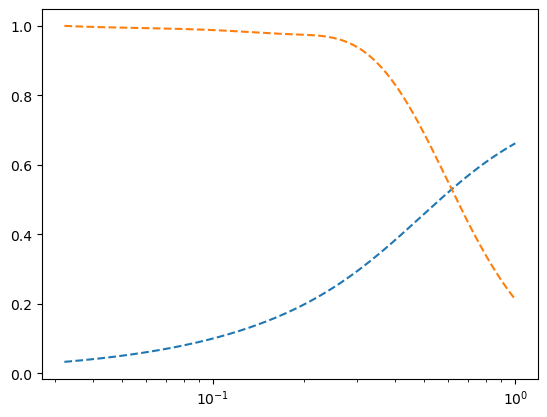

In [18]:
Np_vec = np.linspace(N_p_0, N_p_f, 10000).astype(np.float64)  

a_vec  = np.exp(n_0 * Np_vec)


N_phys = n_0 * Np_vec
a_phys = np.exp(N_phys)

solver_clase = DeltaSolver(Om_m_0=Om_m_0, b=b, k=k_val1)
solver_clase.z_ini_HS = z_0  
num_points = 1000
H_interp, Hprime_interp, r_interp = solver_clase.H_HS()
a_mg, delta_mg, delta_p_mg = solver_clase.solve_delta_mg(num_points=num_points)
delta_mg_interp   = interp1d(a_mg, delta_mg, bounds_error=False, fill_value="extrapolate")
delta_p_mg_interp = interp1d(a_mg, delta_p_mg, bounds_error=False, fill_value="extrapolate")

# Calculamos dónde empieza la red exactamente
a_ini_net = np.exp(n_0 * N_p_0)
z_ini_net = (1.0/a_ini_net) - 1.0

# Aseguramos que el fondo cubra ese inicio
solver_clase.z_ini_HS = max(solver_clase.z_ini_HS, z_ini_net + 2.0)
H_interp, Hprime_interp, r_interp = solver_clase.H_HS()

# --- 2. Definir TU Condición Inicial (Idéntica a la Red) ---
# En la red: X = -n_0  => delta = exp(-n_0)
# En la red: X' = n_0  => delta' = delta / a  (derivada respecto a 'a')
delta_0 = np.exp(-n_0)
delta_p_0 = delta_0 / a_ini_net 

y0_custom = [delta_0, delta_p_0]

# --- 3. Resolver EDO usando la física de tu clase ---
# Usamos 'solver_clase.delta_mg' que ya tiene las ecuaciones cargadas
fun_ode = lambda a, y: solver_clase.delta_mg(a, y, H_interp, Hprime_interp, r_interp)

sol_num = solve_ivp(
    fun_ode, 
    t_span=[a_ini_net, a_phys[-1]], 
    y0=y0_custom, 
    t_eval=a_phys, 
    method='RK45', 
    rtol=1e-12, atol=1e-12
)

# Resultados directos (sin interpolar porque usamos t_eval=a_phys)
delta_num = sol_num.y[0]
delta_p_num = sol_num.y[1]

# --- 4. Plot (Tu código) ---
plt.plot(a_phys, delta_num, label="MG (HS) numérico (CI Red)", ls="--")
plt.plot(a_phys, delta_p_num, label="MG (HS) numérico p (CI Red)", ls="--")
plt.xscale('log')


<>:15: SyntaxWarning: invalid escape sequence '\O'
<>:26: SyntaxWarning: invalid escape sequence '\O'
<>:15: SyntaxWarning: invalid escape sequence '\O'
<>:26: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_11985/2318017616.py:15: SyntaxWarning: invalid escape sequence '\O'
  plt.title(f"Comparación: $\Omega_{{m0}}$ ={Om_m_0}, k = {k_val}h, b = {b}")
/tmp/ipykernel_11985/2318017616.py:26: SyntaxWarning: invalid escape sequence '\O'
  plt.title(f"Diferencia porcentual $\Omega_{{m0}}$ ={Om_m_0}, k = {k_val}h, b = {b}")


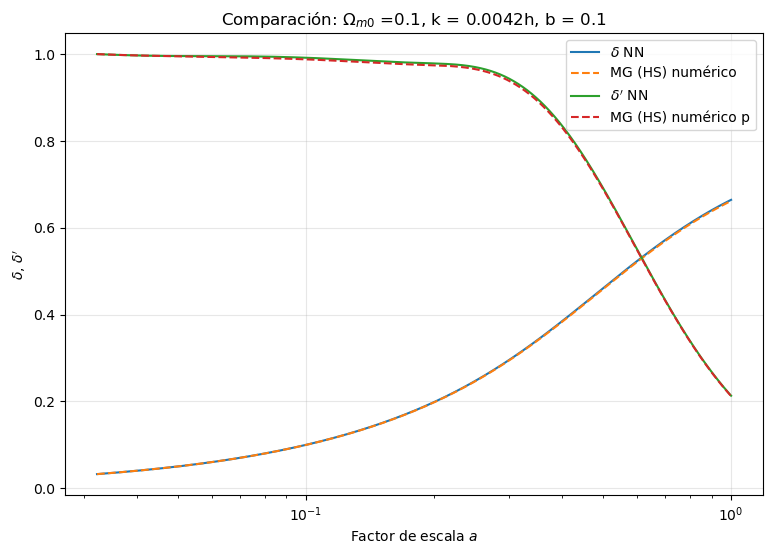

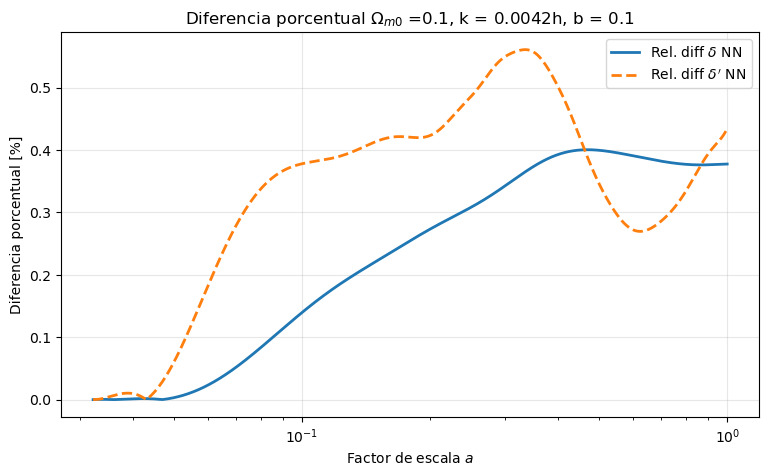

In [19]:

rel_diff_delta   = 100 * np.abs((delta_nn_nb - delta_num) / delta_num)
rel_diff_delta_p = 100 * np.abs((delta_p_nn_nb - delta_p_num) / delta_p_num)


plt.figure(figsize=(9,6))

plt.plot(a_phys, delta_nn_nb, label=r'$\delta$ NN')
plt.plot(a_phys, delta_num, label="MG (HS) numérico", ls="--")
plt.plot(a_phys, delta_p_nn_nb, label=r'$\delta^\prime$ NN')
plt.plot(a_phys, delta_p_num, label="MG (HS) numérico p", ls="--")

plt.xscale("log")
plt.xlabel(r"Factor de escala $a$")
plt.ylabel(r"$\delta$, $\delta^\prime$")
plt.title(f"Comparación: $\Omega_{{m0}}$ ={Om_m_0}, k = {k_val}h, b = {b}")
plt.legend()
plt.grid(True, alpha=0.3)
#plt.savefig(os.path.join(save_dir, f"Comparacion Om ={Om_m_0}, k = {k_eff}, b = {b}, lr = {learning_rate}, iteraciones = {iterations}, batch_size = {batch_size}, hidden units {capas}.png"))
plt.figure(figsize=(9,5))
plt.plot(a_phys, rel_diff_delta, label=r'Rel. diff $\delta$ NN', lw=2)

plt.plot(a_phys, rel_diff_delta_p, label=r'Rel. diff $\delta^\prime$ NN', lw=2, ls='--')
plt.xscale('log')
plt.xlabel("Factor de escala $a$")
plt.ylabel("Diferencia porcentual [%]")
plt.title(f"Diferencia porcentual $\Omega_{{m0}}$ ={Om_m_0}, k = {k_val}h, b = {b}")
plt.grid(True, alpha=0.3)
plt.legend()
#plt.savefig(os.path.join(save_dir, f"Diferencia porcentual Om ={Om_m_0}, k = {k_eff}, b = {b}, lr = {learning_rate}, iteraciones = {iterations}, batch_size = {batch_size}, hidden units {capas}.png"))
plt.show()

COn Bundle

### Dos parámetros de Bundle

Training Progress:   0%|          | 0/1000000 [00:00<?, ?it/s]

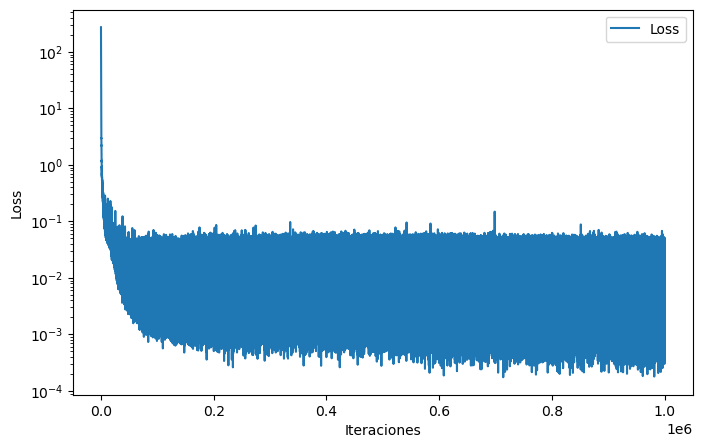

Mejores redes guardadas en: /home/javier-pineau/Escritorio/codigos tesis final/Entrenamiento condiciones iniciales bundle/Bundle Om b=1 k=0.2, lr=0.001, iter=1000000, batch=128, hidden=(64, 32, 32, 16).pt


In [ ]:
b_fixed = 1  

def ODE_MG_NN_Bundle_Analytic_Om(X, X_p, N_p, Om_m_tensor, b_val, k_param, H_0, Lambda):
    N = N_p * n_0 
    a = torch.exp(N)
    z = (1.0 / a) - 1.0
    

    b_tensor = b_val * torch.ones_like(N_p)
    
    theta_bundle = [b_tensor, Om_m_tensor, H_0]

    H_t = H_torch_optimized(z, theta_bundle, r_prime, v)
    mu_t = Geff_torch_optimized(z, k_param, theta_bundle, Lambda, r_prime)

    dH_dz = dH_dz_analytica_torch(z, theta_bundle, r_prime, v, x_sol_obj)
    
    dH_da = dH_dz * (-1.0 / (a ** 2))
    
    # Limpieza
    mu_t = torch.nan_to_num(mu_t, nan=1.0, posinf=1.0, neginf=1.0)

    # EDO Riccati
    H_t = H_t.view(-1, 1)
    dH_t = dH_da.view(-1, 1)
    mu_t = mu_t.view(-1, 1)
    Om_m_col = Om_m_tensor.view(-1, 1)
    
    denom = (H_t ** 2) * (a ** 3)
    term1 = n_0 * ((dH_t / H_t) * a + 2)
    pref = (3 * Om_m_col * (n_0 ** 2) * (H_0 ** 2)) / 2
    term2 = pref * (mu_t / denom)

    res1 = diff(X, N_p) - X_p
    res2 = diff(X_p, N_p) + (X_p ** 2) + (term1 * X_p) - term2

    return [res1, res2]

batch_size = 128
Om_min, Om_max = 0.1, 0.4
k_train = k_val
capas = (64, 64,)

lr = 10e-4

tgz = Generator1D(batch_size, N_p_0, N_p_f, 'equally-spaced-noisy')
vgz = Generator1D(batch_size, N_p_0, N_p_f, 'equally-spaced-noisy')

tg_O = Generator1D(batch_size, Om_min, Om_max, 'equally-spaced-noisy')
vg_O = Generator1D(batch_size, Om_min, Om_max, 'equally-spaced-noisy')

train_gen = tgz ^ tg_O
valid_gen = vgz ^ vg_O

# Redes y Solver
# --- CAMBIO: n_input_units = 2 (Tiempo, Omega) ---
nets = [FCNN(n_input_units=2, hidden_units=capas) for _ in range(2)]
adam = torch.optim.Adam(set([p for net in nets for p in net.parameters()]), lr=lr)

condition = [BundleIVP(N_p_0, -n_0),
             BundleIVP(N_p_0, n_0)]

def weighted_loss(res, x, t): 
    return (res**2).mean()

solver = BundleSolver1D(
    # La lambda ahora recibe: X, X_p, N_p, Om_gen (El orden importa)
    ode_system=lambda X, X_p, N_p, Om_gen: ODE_MG_NN_Bundle_Analytic_Om(
        X, X_p, N_p, Om_gen, b_fixed, k_train, H_0, Lambda
    ),
    nets=nets,
    conditions=condition,
    t_min=N_p_0, t_max=N_p_f,
    n_batches_valid=0,
    theta_min=(Om_min,), 
    theta_max=(Om_max,),
    eq_param_index=(0,), # Solo hay 1 parámetro extra aparte del tiempo
    optimizer=adam,
    train_generator=train_gen,
    valid_generator=valid_gen,
    loss_fn=weighted_loss,
)

# EJECUCIÓN
iterations = 1000000
solver.fit(iterations)

nombre_red = f'Bundle Om b={b_fixed} k={k_val1}, lr={lr}, iter={iterations}, batch={batch_size}, hidden={capas}'
loss = solver.metrics_history['train_loss']

# Save
save_dir = "/home/javier-pineau/Escritorio/codigos tesis final/Entrenamiento condiciones iniciales bundle"
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(np.arange(len(loss)), loss, label='Loss')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
#plt.title(f'Loss (Bundle Om, b={b_fixed}, k={k_val})')
plt.savefig(os.path.join(save_dir, f"{nombre_red}.png"))
plt.show()

save_path = os.path.join(save_dir, nombre_red + ".pt")
# Nota: weights_only=False suele ser necesario para guardar diccionarios completos
torch.save(solver._get_internal_variables()['best_nets'], save_path)
print(f"Mejores redes guardadas en: {save_path}")

In [109]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [115]:
nets_delta = torch.load('/home/javier-pineau/Escritorio/codigos tesis final/Entrenamiento condiciones iniciales bundle/Bundle Om b=1 k=0.2, lr=0.001, iter=1000000, batch=128, hidden=(64, 32, 32, 16).pt', map_location=device, weights_only=False)

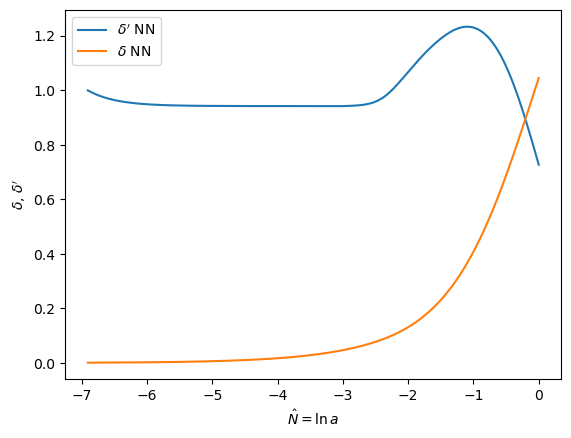

In [119]:
Om_m_0 = 0.345

condition = [BundleIVP(N_p_0, -n_0),
             BundleIVP(N_p_0, n_0)]

sol = BundleSolution1D(nets_delta, condition)

b_val_fijo = 1.0 

def x(N, Om_m_0):
    Om_m_vec = Om_m_0 * np.ones_like(N)
    xs = sol(N, Om_m_vec, to_numpy=True)[0] 
    return xs

def y(N, Om_m_0):
    Om_m_vec = Om_m_0 * np.ones_like(N)
    ys = sol(N, Om_m_vec, to_numpy=True)[1]
    return ys

'''Define a vector in the range of the training values and next evaluate the functions
   defined before in this vector.
'''

N_vec = np.linspace(N_p_0, N_p_f,10000)

a_vec = np.exp(n_0 * N_vec)

'''In this code we load the bundle solution for only one value of Om_m_0. You can put any
   value of this parameter (in the range 0-1) and evaluate the solution of the networks.
'''

Om_m = Om_m_0

Om_L = 1 - Om_r_0 - Om_m
a_eq = Om_r_0 / Om_m 
alpha = a_eq**3 * Om_L / Om_m

x_nn_B=x(N_vec, Om_m)
y_nn_B=y(N_vec, Om_m)


delta_p_nn_B=np.exp(x_nn_B)*y_nn_B/(n_0*a_vec)
#delta_p_num=np.exp(x_num)*y_num/(n_0*a_vec)
delta_nn_B=np.exp(x_nn_B)
#delta_num=np.exp(x_num)
N=N_vec*n_0

'''Plot the NN solution and the numerical one to make a visual comparison.
'''

a=np.exp(N)

plt.figure()
plt.plot(N, delta_p_nn_B,label=r'$\delta^\prime$ NN')
#plt.plot(N, delta_p_num,label=r'$\delta^\prime$ Num')
plt.plot(N, delta_nn_B, label=r'$\delta$ NN')
#plt.plot(N, delta_num, label=r'$\delta$ Num')
plt.xlabel(r'$\hat{N} = \ln{a}$')
plt.ylabel(r'$\delta$, $\delta^\prime$')
plt.legend()
plt.show()



In [120]:
solver_clase = DeltaSolver(Om_m_0=Om_m_0, b=b, k=k_val)
solver_clase.z_ini_HS = z_0  
num_points = 1000
H_interp, Hprime_interp, r_interp = solver_clase.H_HS()
a_mg, delta_mg, delta_p_mg = solver_clase.solve_delta_mg(num_points=num_points)
delta_mg_interp   = interp1d(a_mg, delta_mg, bounds_error=False, fill_value="extrapolate")
delta_p_mg_interp = interp1d(a_mg, delta_p_mg, bounds_error=False, fill_value="extrapolate")

delta_num = delta_mg_interp(a)
delta_p_num = delta_p_mg_interp(a)

#### Comparación contra numérico puro

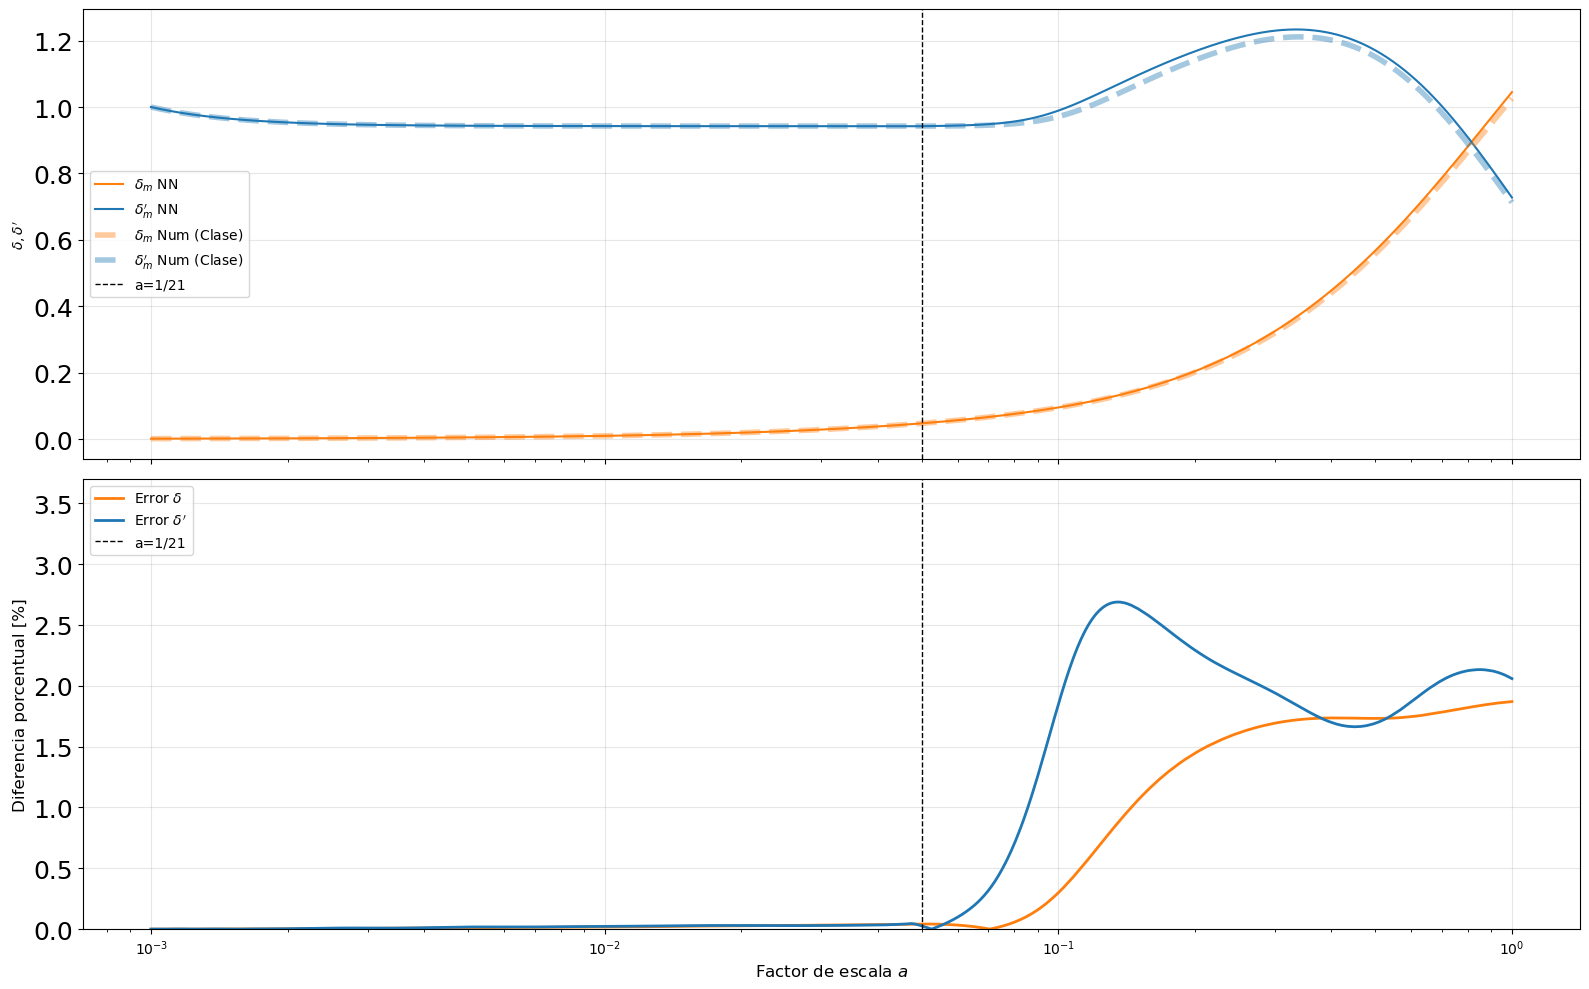

In [121]:
diff_delta = 100 * np.abs((delta_nn_B - delta_num) / delta_num)
diff_delta_p = 100 * np.abs((delta_p_nn_B - delta_p_num) / delta_p_num)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(16, 10))
c_d, c_p = 'tab:orange', 'tab:blue'


ax1.plot(a_vec, delta_nn_B, color=c_d, ls='-', lw=1.5, label=r'$\delta_m$ NN')
ax1.plot(a_vec, delta_p_nn_B, color=c_p, ls='-', lw=1.5, label=r'$\delta^\prime_m$ NN')
ax1.plot(a_vec, delta_num,  color=c_d, ls='--', lw=4, alpha=0.4, label=r'$\delta_m$ Num (Clase)')
ax1.plot(a_vec, delta_p_num, color=c_p, ls='--', lw=4, alpha=0.4, label=r'$\delta^\prime_m$ Num (Clase)')
ax1.axvline(x=1/20, color='black', linestyle='--', label = 'a=1/21', linewidth=1)


ax1.set_xscale('log'); ax1.grid(True, alpha=0.3)
ax2.set_xlabel('a'); ax1.set_ylabel(r'$\delta, \delta^\prime$')
ax1.legend(loc='upper left')

ax2.plot(a_vec, diff_delta, color=c_d, ls='-', lw=2, label=r'Error $\delta$')
ax2.plot(a_vec, diff_delta_p, color=c_p, ls='-', lw=2, label=r'Error $\delta^\prime$')
ax2.set_xscale('log')
ax2.set_xlabel(r"Factor de escala $a$", fontsize=12)
ax2.set_ylabel("Diferencia porcentual [%]", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.axvline(x=1/20, color='black', linestyle='--', label = 'a=1/21', linewidth=1)

ax1.tick_params(axis='y', labelsize=18) 
ax2.tick_params(axis='y', labelsize=18)

ax1.legend(loc='center left', bbox_to_anchor=(0, 0.5))
ax2.legend(loc='upper left')
ax2.set_ylim(0, 3.7)

plt.tight_layout()

plt.savefig(f'solución bundle más diferencia H num Om = {Om_m_0}, b={b}, k={k_val1}.png')

plt.show()

#### Comparación contra numérico H red

### Estoy seguro que esto se puede optimizar pero no se me ocurre cómo y además tengo que terminar de escribir la tesis, sí sé que funciona esto

🧮 Ejecutando Scipy solve_ivp...


/tmp/ipykernel_9857/262300910.py:138: RuntimeWarning: overflow encountered in exp
  r_prime_exp = np.exp(r_prime_sol)
/tmp/ipykernel_9857/262300910.py:150: RuntimeWarning: divide by zero encountered in divide
  term = 1.0 / (3.0 + 1.0 / epsilon)
/tmp/ipykernel_9857/262300910.py:142: RuntimeWarning: overflow encountered in square
  FR = 1.0 - 2.0 / (b * (denomFR ** 2))
/tmp/ipykernel_9857/262300910.py:143: RuntimeWarning: overflow encountered in power
  FRR = 4.0 / (Lambda_val * b**2 * (denomFR ** 3))


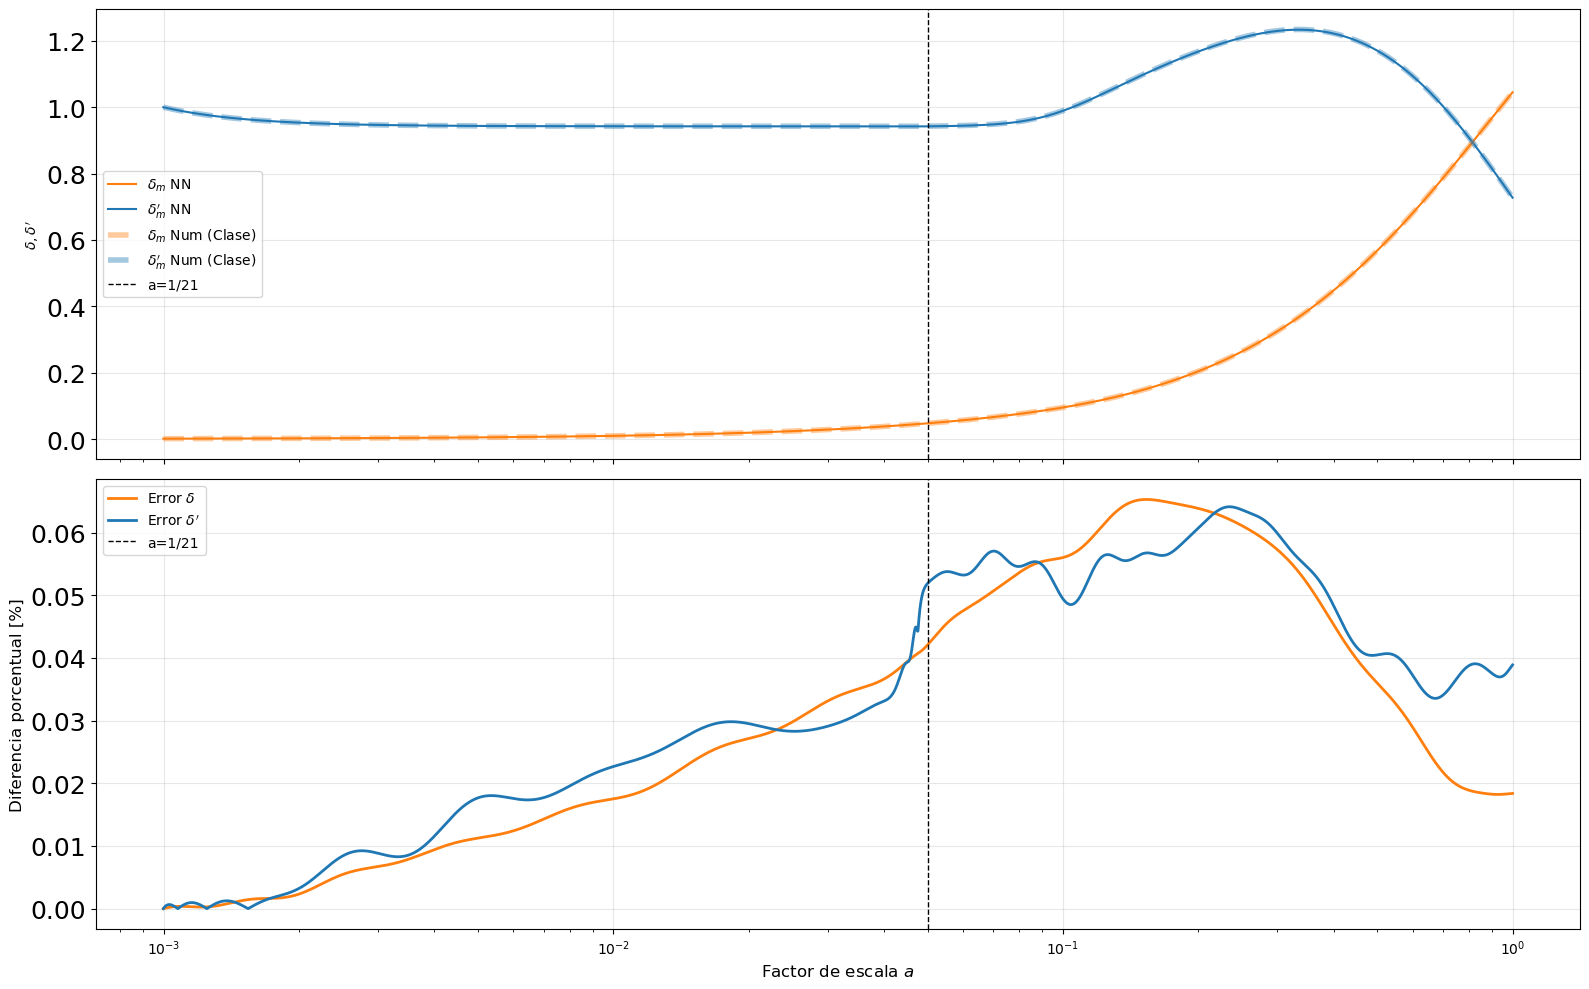

In [ ]:
model = 'Hu-Sawicki'
path = f'/home/javier-pineau/Escritorio/Tesis/Códigos Augusto/f_R_nets_for_multiuse/{model}_nets'

with open(f'{path}/saved_config.yaml') as yaml_file_f_R:
    try:
        Config_f_R = yaml.safe_load(yaml_file_f_R)
    except yaml.YAMLError as exc:
        print(exc)

# Set the range of the independent variable:

z_rescale = z_0

z_prime_min = 0.0
z_prime_max = 1.0
z_min = z_prime_min
z_max = z_rescale * z_prime_max

# Set the range of the parameters of the bundle:
b_prime_min = float(Config_f_R['b_prime_min'])
b_prime_max = 1.0
b_max = Config_f_R['b_max']
b_min = b_prime_min * b_max

Om_m_0_min = Config_f_R['Om_m_0_min']
Om_m_0_max = Config_f_R['Om_m_0_max']

# Set neural network parameters and renormalizations:
alpha_nominator = Config_f_R['alpha_nominator']
alpha_denominator = Config_f_R['alpha_denominator']
alpha = alpha_nominator / alpha_denominator

# Cargar solo las redes necesarias para H(z)
nets = torch.load(f'{path}/nets_f_R.ph', map_location=torch.device('cpu'), weights_only=False)

f_R = f_R_reparams(z_0=z_0, b_prime_min=b_prime_min, b_max=b_max, alpha=alpha)

conditions = [
    CustomCondition(f_R.v_reparam),
    CustomCondition(f_R.r_prime_reparam)
 ]

r_prime_net_index = -1
v_net_index = 2

r_prime = BundleSolution1D([nets[r_prime_net_index]], [conditions[-1]])
v = BundleSolution1D([nets[v_net_index]], [conditions[0]])

def H(z, theta, **kwargs):
    """Función que calcula el parámetro de Hubble H(z)"""
    b, Om_m_0, H_0 = theta  
    
    z_prime = 1 - (z / z_rescale)
    b_prime = b / b_max

    if kwargs.pop('post', False):
        z_prime = z_prime * np.ones_like(b_prime)
        no_reshape = False
    else:
        shape, no_reshape = _shape_manager(z, b, Om_m_0)
        b_prime = b_prime * shape
        Om_m_0 = Om_m_0 * shape

    # --- DEVICE & DTYPE FIX: ensure all tensors are on the same device and dtype as the network ---
    net_device = next(r_prime.nets[0].parameters()).device
    net_dtype = next(r_prime.nets[0].parameters()).dtype
    import torch
    def to_tensor_on_device_dtype(arr):
        if isinstance(arr, np.ndarray):
            return torch.tensor(arr, dtype=net_dtype, device=net_device)
        elif isinstance(arr, float) or isinstance(arr, int):
            return torch.tensor([arr], dtype=net_dtype, device=net_device)
        elif torch.is_tensor(arr):
            return arr.to(device=net_device, dtype=net_dtype)
        else:
            return arr

    z_prime_t = to_tensor_on_device_dtype(z_prime)
    b_prime_t = to_tensor_on_device_dtype(b_prime)
    Om_m_0_t = to_tensor_on_device_dtype(Om_m_0)

    r_prime_sol = r_prime(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=True, no_reshape=no_reshape)
    v_sol = v(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=True, no_reshape=no_reshape)

    out = H_0 * np.sqrt(((1 - Om_m_0) / 2) * np.exp(r_prime_sol) / v_sol)

    if no_reshape:
        out = out[0][0]
    return out



z_examples = np.linspace(0, z_0, 10000) # Hay que hacer que coincida con los que uso para entrenar la red. 

theta_example = [b, Om_m_0, H_0]


H_values = H(z_examples, theta_example)

solver_clase = DeltaSolver(Om_m_0=Om_m_0, b=b, k=k)
solver_clase.z_ini_HS = z_0  

H_interp, Hprime_interp, r_interp = solver_clase.H_HS()

def Geff_G_func(z, k, b, Om_m_0, Lambda_val, debug=False, **kwargs):
    z_prime = 1 - (z / z_rescale)
    b_prime = b / b_max

    if kwargs.pop('post', False):
        z_prime = z_prime * np.ones_like(b_prime)
        no_reshape = False
    else:
        shape, no_reshape = _shape_manager(z, b, Om_m_0)
        b_prime = b_prime * shape
        Om_m_0 = Om_m_0 * shape

    # --- DEVICE & DTYPE FIX: ensure all tensors are on the same device and dtype as the network ---
    net_device = next(r_prime.nets[0].parameters()).device
    net_dtype = next(r_prime.nets[0].parameters()).dtype
    
    def to_tensor_on_device_dtype(arr):
        if isinstance(arr, np.ndarray):
            return torch.tensor(arr, dtype=net_dtype, device=net_device)
        elif isinstance(arr, float) or isinstance(arr, int):
            return torch.tensor([arr], dtype=net_dtype, device=net_device)
        elif torch.is_tensor(arr):
            return arr.to(device=net_device, dtype=net_dtype)
        else:
            return arr

    z_prime_t = to_tensor_on_device_dtype(z_prime)
    b_prime_t = to_tensor_on_device_dtype(b_prime)
    Om_m_0_t = to_tensor_on_device_dtype(Om_m_0)

    r_prime_sol = r_prime(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=True, no_reshape=no_reshape)
    v_sol = v(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=True, no_reshape=no_reshape)

    r_prime_exp = np.exp(r_prime_sol)

    denomFR = 1.0 + (r_prime_exp * Lambda_val) / (Lambda_val * b)  

    FR = 1.0 - 2.0 / (b * (denomFR ** 2))
    FRR = 4.0 / (Lambda_val * b**2 * (denomFR ** 3))

    m = FRR / FR
    
    # CORRECCIÓN: Usamos 'k' (el argumento de la función) en lugar de 'k_val'
    epsilon = (k**2) * (1.0 + z)**2 * m

    term = 1.0 / (3.0 + 1.0 / epsilon)
    Geff_over_G = (1.0 / FR) * (1.0 + term)

    return Geff_over_G


x_net_index = 0
x_condition = CustomCondition(f_R.x_reparam)
x = BundleSolution1D([nets[x_net_index]], [x_condition])

def dH_dz_red(z, theta):
    b, Om_m_0, H_0_local = theta

    z = np.asarray(z)
    z_prime = 1 - (z / z_rescale)
    b_prime = np.full_like(z, b / b_max)
    Om_m_0_arr = np.full_like(z, Om_m_0)

    # Ensure correct device and dtype for all network inputs
    net_device = next(r_prime.nets[0].parameters()).device
    net_dtype = next(r_prime.nets[0].parameters()).dtype
    import torch
    def to_tensor_on_device_dtype(arr):
        if isinstance(arr, np.ndarray):
            return torch.tensor(arr, dtype=net_dtype, device=net_device)
        elif isinstance(arr, float) or isinstance(arr, int):
            return torch.tensor([arr], dtype=net_dtype, device=net_device)
        elif torch.is_tensor(arr):
            return arr.to(device=net_device, dtype=net_dtype)
        else:
            return arr

    z_prime_t = to_tensor_on_device_dtype(z_prime)
    b_prime_t = to_tensor_on_device_dtype(b_prime)
    Om_m_0_t = to_tensor_on_device_dtype(Om_m_0_arr)

    r_prime_sol = r_prime(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=False)
    v_sol = v(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=False)
    x_sol = x(z_prime_t, b_prime_t, Om_m_0_t, to_numpy=False)

    dtype = r_prime_sol.dtype
    device = r_prime_sol.device

    r = torch.exp(r_prime_sol)
    b_tensor = torch.as_tensor(b_prime * b_max, dtype=dtype, device=device)
    Om_m_0_tensor = torch.as_tensor(Om_m_0_arr, dtype=dtype, device=device)
    z_tensor = torch.as_tensor(z, dtype=dtype, device=device)

    Gamma = (r + b_tensor) * (((r + b_tensor) ** 2) - 2.0 * b_tensor) / (4.0 * b_tensor * r)
    denom = z_tensor + 1.0

    dr_dz = - r * Gamma * x_sol / denom
    dv_dz = - v_sol * (x_sol * Gamma + 4.0 - 2.0 * v_sol) / denom

    coef1 = 0.25 * (1.0 - Om_m_0_tensor)
    coef2 = torch.sqrt(r / (2.0 * v_sol) * (1.0 - Om_m_0_tensor))

    dH = coef1 / coef2 * (dr_dz / v_sol - r * dv_dz / (v_sol ** 2))
    return dH.detach().cpu().numpy()

theta_example = [b, Om_m_0, H_0]

dH_net_values = H_0 * dH_dz_red(z_examples, theta_example)


H_interp_class, Hprime_interp_class, r_interp_class = solver_clase.H_HS()
z_range_class = np.linspace(0, solver_clase.z_ini_HS, 10000)
H_class = H_interp_class(z_range_class) * H_0  
r_class = r_interp_class(z_range_class)
z_vec_class, x_vec_class, v_vec_class, r_vec_class = solver_clase.integ_HS()
v_interp_class = interp1d(z_vec_class, v_vec_class, bounds_error=False, fill_value="extrapolate")
v_class = v_interp_class(z_range_class)


dH_dz_clase_values =H_0* solver_clase.dH_dz(z=z_range_class, r=r_class, v=v_class, x=x_vec_class)
dH_dz_clase_values = np.asarray(dH_dz_clase_values)
dH_net_values = np.asarray(dH_net_values)


dH_interp_class_to_examples = interp1d(z_range_class, dH_dz_clase_values, bounds_error=False, fill_value="extrapolate")

dH_dz_clase = dH_interp_class_to_examples(z_examples)

# Derivadas de red + expresión analítica de LCDM pegadas

def H_LCDM(a):
    inside = Om_L_0 + Om_m_0 / (a ** 3) + Om_r_0 / (a ** 4)
    return H_0 * np.sqrt(inside)

def dH_da_LCDM(a):
    numerator = -3.0 * Om_m_0 * (a ** (-4)) - 4 * Om_r_0 * (a ** (-5))
    raiz = np.sqrt(Om_L_0 + Om_m_0 / (a ** 3) + Om_r_0 / (a ** 4))
    dHda_ana = H_0 * numerator / (2 * raiz)
    return dHda_ana


z_lcdm = np.linspace(z_0, 1000, 10000)

dH_net_values =H_0* dH_dz_red(z_examples, theta_example)
da_dz = -1.0 / (1.0 + z_lcdm)**2

#LCDM

H_LCDM_segment = H_LCDM(1.0 / (1.0 + z_lcdm)) 
dH_dz_tramo_LCDM = dH_da_LCDM(1.0 / (1.0 + z_lcdm))*da_dz

#MG

H_MG_segment = H_values 
dH_dz_tramo_MG = dH_net_values 


z_comb = np.concatenate((z_examples, z_lcdm[1:]))
H_comb = np.concatenate((H_MG_segment, H_LCDM_segment[1:]))
dH_dz_comb = np.concatenate((dH_dz_tramo_MG, dH_dz_tramo_LCDM[1:]))

order = np.argsort(z_comb)
z_total = z_comb[order]
H_total = H_comb[order]
dH_dz_total = dH_dz_comb[order]

#sacar lo de abajo y ver qué pasa

mask = np.ones_like(z_total, dtype=bool)
z_clean = z_total #[mask]
H_clean = H_total#[mask]
dH_dz_clean = dH_dz_total#[mask]


device = torch.device('cpu') # Forzamos CPU para evitar conflictos con Scipy

# A) Redes de Background (si existen)
if 'r_prime' in globals():
    for net in r_prime.nets:
        net.to(device)
        net.float() # float32
if 'v' in globals():
    for net in v.nets:
        net.to(device)
        net.float()

# B) Redes del Solver (entrenadas)
if 'solver_nn' in globals():
    target_nets = solver_nn.nets
else:
    target_nets = nets # Fallback

for net in target_nets:
    net.to(device)
    net.float()
    net.eval()

def ODE_MG_num_Hred(N_p, x_val, k_param, b, Om_m_0, Lambda):
    N = N_p * n_0
    a = np.exp(N)
    a_scalar = a.item() if np.ndim(a) == 0 else a
    z_scalar = (1.0 / a_scalar) - 1.0
    
    H_z = np.interp(z_scalar, z_total, H_total)
    dHdz = np.interp(z_scalar, z_total, dH_dz_total)
    dHda = dHdz * (-1.0 / (a_scalar ** 2))
    
    mu_res = Geff_G_func(z_scalar, k_param, b, Om_m_0, Lambda)
    mu_val = mu_res.item() if mu_res.size == 1 else mu_res[0]
    
    if z_scalar > z_0:
        mu_val = 1.0 

    term1 = n_0 * ((dHda / H_z) * a_scalar + 2)
    denom = (H_z ** 2) * (a_scalar ** 3)
    term2 = 1.5 * (Om_m_0 * (n_0 ** 2) * (H_0 ** 2)) * (mu_val / denom)
    
    return np.array([x_val[1], -x_val[1]**2 - term1 * x_val[1] + term2])


k_input_num = k_val
y0_num = [-n_0, n_0] 
N_eval = np.linspace(N_p_0, N_p_f, 10000)

print("🧮 Ejecutando Scipy solve_ivp...")
sol_check = solve_ivp(
    fun=ODE_MG_num_Hred, 
    t_span=[N_p_0, N_p_f], 
    y0=y0_num, 
    t_eval=N_eval, 
    method='RK45', 
    args=(k_input_num, b, Om_m_0, Lambda),
    rtol=1e-10, atol=1e-12
)

# Datos Numéricos
a_num = np.exp(sol_check.t * n_0)
delta_num_H_red = np.exp(sol_check.y[0])
delta_p_num_H_red = delta_num_H_red * sol_check.y[1] / (n_0 * a_num)

# Error
delta_num_interp = np.interp(a_vec, a_num, delta_num_H_red)
delta_p_num_interp = np.interp(a_vec, a_num, delta_p_num_H_red)
diff_delta = 100 * np.abs((delta_nn_B - delta_num_interp) / delta_num_interp)
diff_delta_p = 100 * np.abs((delta_p_nn_B - delta_p_num_interp) / delta_p_num_interp)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(16, 10))
c_d, c_p = 'tab:orange', 'tab:blue'


ax1.plot(a_vec, delta_nn_B, color=c_d, ls='-', lw=1.5, label=r'$\delta_m$ NN')
ax1.plot(a_vec, delta_p_nn_B, color=c_p, ls='-', lw=1.5, label=r'$\delta^\prime_m$ NN')
ax1.plot(a_vec, delta_num_H_red,  color=c_d, ls='--', lw=4, alpha=0.4, label=r'$\delta_m$ Num (Clase)')
ax1.plot(a_vec, delta_p_num_H_red, color=c_p, ls='--', lw=4, alpha=0.4, label=r'$\delta^\prime_m$ Num (Clase)')
ax1.axvline(x=1/20, color='black', linestyle='--', label = 'a=1/21', linewidth=1)


ax1.set_xscale('log'); ax1.grid(True, alpha=0.3)
ax2.set_xlabel('a'); ax1.set_ylabel(r'$\delta, \delta^\prime$')
ax1.legend(loc='upper left')

ax2.plot(a_vec, diff_delta, color=c_d, ls='-', lw=2, label=r'Error $\delta$', labelsize=12)
ax2.plot(a_vec, diff_delta_p, color=c_p, ls='-', lw=2, label=r'Error $\delta^\prime$')
ax2.set_xscale('log')
ax2.set_xlabel(r"Factor de escala $a$", fontsize=12)
ax2.set_ylabel("Diferencia porcentual [%]", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.axvline(x=1/20, color='black', linestyle='--', label = 'a=1/21', linewidth=1)

ax1.tick_params(axis='y', labelsize=18) 
ax2.tick_params(axis='y', labelsize=18)

ax1.legend(loc='center left', bbox_to_anchor=(0, 0.5))
ax2.legend(loc='upper left')
#ax2.set_ylim(0, 3.7)

plt.tight_layout()

#plt.savefig(f'solución bundle más diferencia H num Om = {Om_m_0}, b={b}, k={k_val1}.png')

plt.show()